In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
import torch
import torch.nn as nn
import torch.nn.functional as F
from mamba_model import Mamba, MambaConfig
import argparse
from DataProcessing import HankelMatrices, HankelMatricesSequences, Sequence2Sequence, Sequence2SequenceStates,Sequence2SequenceFuture
import scipy.io
import l4casadi as l4c
from casadi import *
import casadi as cs
from casadi.tools import *
import time

In [3]:
def setup_NMPC(n_x, n_u, N, Ts, Q, R, Rd, S):
    # Sys ID:
    M = 1          # mass of the pendulum
    L = 1          # lenght of the pendulum
    b = 0.1         # friction coefficient
    g = 9.81        # acceleration of gravity
    J = 1/3*M*L**2   # moment of inertia
    
    # Create optimization variables (states and inputs)
    opt_x = struct_symMX([
        entry('x', shape=(n_x), repeat=N + 1),  # N+1 states
        entry('u', shape=(n_u), repeat=N)      # N inputs
    ])

    # Create parameters (initial state, reference, previous input)
    opt_p = struct_symMX([
        entry('x0', shape=(n_x)),          # Initial state
        entry('x_ref', shape=(1), repeat=N), # State reference (for the horizon)
        entry('u_prev', shape=(n_u))        # Previous input (for input rate penalty)
    ])

    # Create numerical instances of the structures (holding all zeros as entries)
    opt_x_num = opt_x(0)
    opt_p_num = opt_p(0)
    
      # Define the objective function
    obj = 0
    for k in range(N):
        x_k = opt_x['x', k]
        # State tracking cost
        obj += Q * cs.sumsqr(x_k[1] - opt_p['x_ref', k])
        # Input cost
        obj += R * cs.sumsqr(opt_x['u', k])
        # Input rate of change cost (using u_prev for the first step)
        if k == 0:
            obj += Rd * cs.sumsqr(opt_x['u', k] - opt_p['u_prev'])
        else:
            obj += Rd * cs.sumsqr(opt_x['u', k] - opt_x['u', k-1])

    # Terminal state cost
    x_k = opt_x['x',N]
    obj += S * cs.sumsqr(x_k[1] - opt_p['x_ref', N-1]) # Correct indexing for terminal cost





    # Define the constraints (system dynamics enforced at each time step)
    constraints = []
    for k in range(N):
        # Get current state and input
        x_k = opt_x['x', k]
        u_k = opt_x['u', k]
        x_k_plus_1 = opt_x['x', k+1]

        # Pendulum dynamics (discrete-time approximation - Forward Euler)
        x1_next = (1-b*Ts/J)*x_k[0]+ (Ts)/J*u_k- (M*L*Ts*g)/(2*J)*np.sin(x_k[1])
        x2_next = Ts*x_k[0]+x_k[1]

        # Enforce dynamics as equality constraints
        constraints.append(x_k_plus_1[0] - x1_next)
        constraints.append(x_k_plus_1[1] - x2_next)

    # Initial state constraint
    constraints.append(opt_x['x', 0] - opt_p['x0'])

    # Concatenate constraints
    cons = cs.vertcat(*constraints)

    # Create lower and upper bound structures and set all values to plus/minus infinity.
    lbx = opt_x(-np.inf)
    ubx = opt_x(np.inf)

    # Set only bounds on u_N
    lbx['u'] = -3
    ubx['u'] = 3

    opts = {'ipopt.print_level': 0, 'print_time': 0}
    solver_opts = {
    'ipopt': {
        'print_level': 5,  # Increase verbosity
        'tol': 1e-8,
        'constr_viol_tol': 1e-6,
        'max_iter': 500
    }
}
    # Create Optim
    # Create the NLP
    nlp = {'x': cs.veccat(opt_x), 'f': obj, 'g': cons, 'p': cs.veccat(opt_p)}
    S_spc = cs.nlpsol('S', 'ipopt', nlp,opts)
    
    return S_spc, opt_x_num, opt_p_num, lbx, ubx

In [4]:
def Pendulum(x1,x2, Ts,u1):
    M = 1          # mass of the pendulum
    L = 1          # lenght of the pendulum
    b = 0.1         # friction coefficient
    g = 9.81        # acceleration of gravity
    J = 1/3*M*L**2   # moment of inertia

    # Calculate the change in angular acceleration
    x1_next = (1-b*Ts/J)*x1+ (Ts)/J*u1- (M*L*Ts*g)/(2*J)*np.sin(x2)
    x2_next = Ts*x1+x2

    return (x1_next, x2_next)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

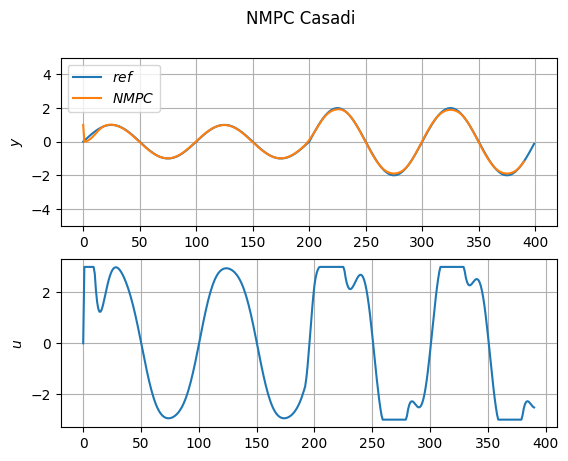

In [17]:
#Sampling Time
Ts = 1/30

# Simulation time
time_range = 4

# Simulation steps
L = round(time_range/(1/100))

# Init time
t = np.arange(L+1)*(1/100)

#Choose the reference
f = 1  # Frequency in Hz
A = 1
#Model Variables
N = 10
Tini = 5

ref =  1*np.sin(2*np.pi*f*t[:200])
ref1 =  2*np.sin(2*np.pi*f*t[:200])
ref = np.concatenate((ref, ref1))
amplitudes = [0.8, 0.5,-0.5,  -0.8]
ref_line = []
# for amplitude in amplitudes:
#     ref_line.extend([amplitude] * 30)

# ref_line = np.array(ref_line)
# ref = np.concatenate((ref, ref_line))
# amplitudes = [0.4, 1.6, -1.6]
# ref = []
# for amplitude in amplitudes:
#     ref.extend([amplitude] * 20)

# Initial state
x1_init = 1
x2_init = 1

x1 = np.zeros(L + 1)
x2 = np.zeros(L + 1)
u = np.zeros(L)

#Maximum input
u_max = 15

#Model Variables
N = 10
Tini = 5

n_u = 1
n_y = 1


# #Controller Variables
Q = 200
R =  0.5
Rd = 0
S = 0



res_SPC = []
res = []
uvec = [0]
yvec = [1]
xvec = [[1,1]]
u_ini = np.zeros(Tini)
y_ini = np.ones(Tini)


S_mpc, opt_x_num, opt_p_num, lbx, ubx = setup_NMPC(2, n_u, N, Ts,Q, R, Rd, S)

cost = []
t_calc = []
u0 = 1

u_ini = np.zeros(Tini-1)
y_ini = np.ones(Tini)
y_ini_list = []
u_ini_list = []
uN = []
yN_NMPC = []

# Set solver options to suppress output
opts = {'ipopt.print_level': 0} 
start_time = time.time()
for k in range(L-N):

    if k == 0:
        y_ini = np.concatenate((y_ini[1:], [x2[k]])) 
        u_ini = u_ini 

    elif k>= 1:
        y_ini = np.concatenate((y_ini[1:], [x2[k]])) 
        u_ini = np.concatenate((u_ini[1:], [uvec[k]])) 

    y_ini_list.append(y_ini)
    u_ini_list.append(u_ini)    

    opt_p_num['x_ref'] = vertsplit(ref[k:k+N])
    opt_p_num['u_prev'] = uvec[k]
    opt_p_num['x0'] = vertcat(x1[k],x2[k])

    

    r = S_mpc(x0 = uvec[k], p=opt_p_num,lbg = 0, ubg =0, lbx=lbx, ubx=ubx)
    

    opt_x_num.master = r['x']  
    u0 = opt_x_num['u',0].full().reshape(-1,1)
    yN_solver = np.array(opt_x_num['x'])
    uN.append(np.array(opt_x_num['u']).reshape(-1,10))
    yN_NMPC.append(yN_solver[:,0,:])
    uvec.append(u0.item())
    #VDP 
    (x1[k+1], x2[k+1]) = Pendulum(x1[k],x2[k], Ts,u0.item())
    yvec.append(x2[k+1])
    xvec.append([x1[k+1], x2[k+1]])
    print(k)

print("--- %s seconds ---" % (time.time() - start_time))
fig, axs = plt.subplots(2)
fig.suptitle("NMPC Casadi")
axs[0].plot(ref, label="$ref$")
axs[0].plot(yvec, label = "$NMPC$")
axs[0].legend()
axs[0].grid()
axs[0].set_ylim(-5, 5)

axs[1].plot(uvec)
axs[0].set(ylabel="$y$")
#axs[1].set(ylabel="theta")
axs[1].set(ylabel="$u$")
axs[1].grid()
plt.show()
fig.savefig("NMPC.png", format='png')

In [6]:
print(np.array(uvec[:530]).shape)
np.save("uvec.npy", uvec[:530])
np.save("yvec.npy", yvec[:530])
np.save("xvec.npy", xvec)

(391,)


In [7]:
# from scipy.io import savemat
# savemat("NMPC.mat", {"uvec": uvec, "yvec": yvec})

In [19]:
yvec = np.array(yvec)
X1 = np.array(x1)
X2 = np.array(x2)
X0 = np.array([X1,X2])
X0 = torch.FloatTensor(X0).transpose(0,1)[:L-N,:]
uN = np.array(uN).reshape(L-N,N)
uN = torch.FloatTensor(np.array(uN))
yN_NMPC = np.array(yN_NMPC)
np.sum(np.abs(yvec[:L-N]-ref[:L-N]))
xvec = torch.FloatTensor(xvec)
uvec = torch.FloatTensor(uvec).unsqueeze(1)
yvec = torch.FloatTensor(yvec)


In [47]:
from scipy.io import savemat

savemat(
    "NMPC"+".mat",
    {'uN': uN, 'u_ini_list': u_ini_list ,  'y_ini_list': y_ini_list})

In [9]:
class NetSequences(nn.Module):
    def __init__(self,in_dim,out_dim,L):
        super().__init__()
        D_model  = 8
        self.config = MambaConfig(d_model=D_model, n_layers=1, expand_factor = 1  , d_conv = 4, d_state = 8)
        self.lin1 = nn.Linear(in_dim,D_model)
        self.mamba = Mamba(self.config)
        self.MLP = nn.Linear(D_model,out_dim)
        

    def forward(self,x):
        # print("Input Shape:"+str(x.shape))
        x = self.lin1(x)
        x = self.mamba(x)
        x = self.MLP(x)
        return x.squeeze(0) 

In [10]:
model = NetSequences(3,2,3)
model.load_state_dict(torch.load("State_dicts/RK4_D8_dstate8_Conv4_Large_N10",map_location=torch.device('cpu'))['model_state_dict'])

C:\Users\Michiel\AppData\Local\Temp\ipykernel_34988\4065888081.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("State_dicts/RK4_D8_dstat

<All keys matched successfully>

In [11]:
# yN = []
# input_set   = torch.tensor(())
# for i in range(L-N):
#     inputs = np.concatenate((u_ini_list[i].T, y_ini_list[i].T, uN[i]))
#     inputs = torch.tensor(inputs, dtype=torch.float).unsqueeze(0)
    
#     input_set = torch.cat((input_set,inputs),0)

# input_set = input_set.unsqueeze(-1)
# print(input_set.shape)
# yN = model(input_set).detach().numpy()
# yN = np.array(yN).reshape(L-N,10)

In [12]:
# uN = torch.tensor(uN)
# testX,testY = Sequence2SequenceStates(X0,uN,torch.zeros(230,10))
# yN = model(testX).detach().numpy()

In [13]:
# uN = torch.tensor(uN)
# u_ini = torch.FloatTensor(np.array(u_ini_list))
# y_ini = torch.FloatTensor(np.array(y_ini_list))
# testX,testY = Sequence2SequenceFuture(u_ini, y_ini ,uN,uN)
# # testX = Sequence2Sequence(u_ini, y_ini, uN)
# batch_size,SequenceLength,Input_dim = testX.shape
# _,_, Output_dim = testY.shape 
# model = NetSequences(Input_dim, Output_dim,Tini)
# model.load_state_dict(torch.load("State_dicts/Tustin_D16_dstate16_Conv4_Large", map_location=torch.device('cpu'))['model_state_dict'])
# yN = model(testX).detach().numpy()


In [14]:
uN = torch.tensor(uN)

# U_0_Nm1, Y_1_N, X0 = HankelMatricesStates(uvec,xvec, N)
X, Y  = Sequence2SequenceStates(X0.unsqueeze(1),uN.unsqueeze(2),uN.unsqueeze(2))

yN = model(X).detach().numpy()

C:\Users\Michiel\AppData\Local\Temp\ipykernel_34988\3298474269.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  uN = torch.tensor(uN)


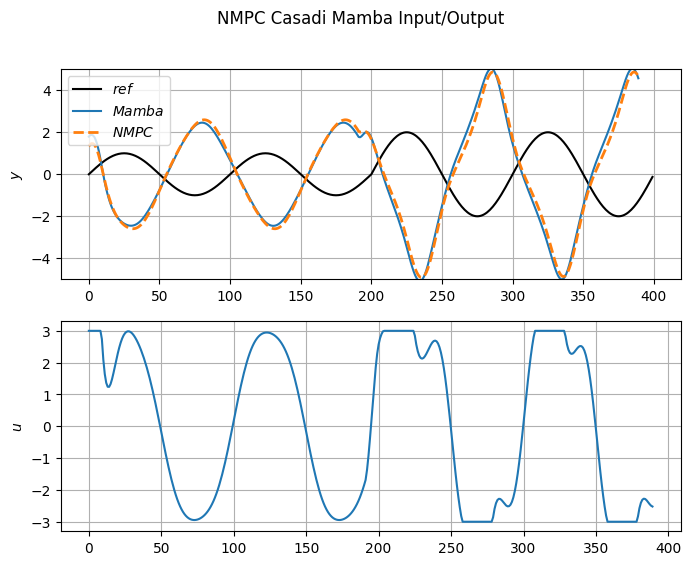

In [22]:
#Sampling Time
Ts = 1/30



# Init time
t = np.arange(L+1)*Ts

mu = 1

# Initial state
x1_init = 1
x2_init = 1

x1 = np.zeros(L + 1)
x2 = np.zeros(L + 1)
u = np.zeros(L)


#Choose the reference
f = 0.1  # Frequency in Hz
A = 2


fig, axs = plt.subplots(2,figsize=(8, 6))
fig.suptitle("NMPC Casadi Mamba Input/Output")
axs[0].plot(ref, 'k',label="$ref$")
axs[0].plot(yN[:,9,0] , label = "$Mamba$")
axs[0].plot(yN_NMPC[:,9,0] , '--', lw =2,  label = "$NMPC$")
axs[0].legend()
axs[0].grid()
axs[0].set_ylim(-5, 5)

axs[1].plot(uN[:,0])
axs[0].set(ylabel="$y$")
#axs[1].set(ylabel="theta")
axs[1].set(ylabel="$u$")
axs[1].grid()
plt.show()
fig.savefig("MambaNMPCInput_A2_States.png", format='png',dpi=300)

In [18]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters (including non-trainable buffers if any): {total_params}")

Total parameters (including non-trainable buffers if any): 1937


In [24]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

# Calculate R-squared
r2 = r2_score(yN_NMPC[:,9,:], yN[:,9,0] )

print(f"R-squared on validation set: {r2}")


R-squared on validation set: 0.9886630578847434
